In [22]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from datetime import datetime, timezone, timedelta
from dataclasses import asdict
import json, tempfile, joblib

from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve)
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
import mlflow

from data_generator.server_simulator import ServerSimulator

# ── Generate dataset with SUBTLE faults ─────────────────────────────────────
# Lower fault_probability + custom fault multipliers = harder to detect
class SubtleFaultSimulator(ServerSimulator):
    """
    Overrides fault injection to produce subtle anomalies:
    - Thermal drift: +5–12°C instead of +20–45°C
    - Power creep:   1.05–1.20x instead of 1.4–2.1x
    - CPU zombie:    0.80–0.92 util instead of 0.92–1.0
    These are realistic early-warning scenarios for predictive maintenance.
    """
    def _inject_fault(self, record: dict) -> dict:
        import random
        fault = random.choice(["thermal_drift", "power_creep", "cpu_zombie"])
        if fault == "thermal_drift":
            record["cpu_temp_c"]     += random.uniform(5, 12)
            record["outlet_temp_c"]  += random.uniform(3, 8)
            if record["cpu_temp_c"] > 75:
                record["cooling_state"] = "warning"
        elif fault == "power_creep":
            record["power_draw_w"]   *= random.uniform(1.05, 1.20)
            record["cpu_power_w"]    *= random.uniform(1.08, 1.22)
        elif fault == "cpu_zombie":
            record["cpu_utilization"] = random.uniform(0.80, 0.92)
            record["cpu_temp_c"]     += random.uniform(5, 12)
        record["is_anomaly"] = True
        return record

srv_sim = SubtleFaultSimulator(
    num_servers=100,
    num_racks=10,
    fault_probability=0.04,
    random_seed=42
)

start_time = datetime(2024, 6, 15, 0, 0, tzinfo=timezone.utc)
records = []
for i in range(288):
    ts = start_time + timedelta(minutes=5 * i)
    records.extend([asdict(r) for r in srv_sim.generate_snapshot(ts)])

df = pd.DataFrame(records)
df['timestamp_utc'] = pd.to_datetime(df['timestamp_utc'], utc=True)
df['hour'] = df['timestamp_utc'].dt.hour

print(f'Total records  : {len(df):,}')
print(f'Anomaly rate   : {df["is_anomaly"].mean():.2%}')
print(f'Anomaly count  : {df["is_anomaly"].sum():,}')
print(f'Normal  count  : {(~df["is_anomaly"]).sum():,}')

2026-03-02 20:11:35.839 | INFO     | data_generator.server_simulator:__init__:91 - ServerSimulator initialized: 100 servers across 10 racks in ZONE-A


Total records  : 28,800
Anomaly rate   : 4.03%
Anomaly count  : 1,160
Normal  count  : 27,640


In [23]:
BASE_FEATURES = [
    'power_draw_w', 'cpu_power_w', 'cpu_utilization',
    'memory_utilization', 'disk_io_utilization', 'network_utilization',
    'cpu_temp_c', 'inlet_temp_c', 'outlet_temp_c',
    'pue_contribution', 'fan_speed_rpm'
]

# ── Feature Engineering ──────────────────────────────────────────────────────
df['temp_delta']         = df['outlet_temp_c'] - df['inlet_temp_c']
df['compute_ratio']      = df['cpu_power_w']   / df['power_draw_w'].clip(lower=1)
df['resource_pressure']  = (df['cpu_utilization'] * 0.5 +
                            df['memory_utilization'] * 0.3 +
                            df['disk_io_utilization'] * 0.2)

# Rolling statistics per server (captures temporal drift)
df = df.sort_values(['server_id', 'timestamp_utc'])
df['cpu_temp_roll_mean'] = (df.groupby('server_id')['cpu_temp_c']
                              .transform(lambda x: x.rolling(6, min_periods=1).mean()))
df['power_roll_std']     = (df.groupby('server_id')['power_draw_w']
                              .transform(lambda x: x.rolling(6, min_periods=1).std().fillna(0)))
df['cpu_util_roll_mean'] = (df.groupby('server_id')['cpu_utilization']
                              .transform(lambda x: x.rolling(6, min_periods=1).mean()))

# Z-score deviation from server's own rolling mean (detects individual drift)
df['temp_zscore']        = ((df['cpu_temp_c'] - df['cpu_temp_roll_mean']) /
                            df['power_roll_std'].clip(lower=0.1))
df['temp_zscore']        = df['temp_zscore'].fillna(0).clip(-5, 5)

ALL_FEATURES = BASE_FEATURES + [
    'temp_delta', 'compute_ratio', 'resource_pressure',
    'cpu_temp_roll_mean', 'power_roll_std', 'cpu_util_roll_mean', 'temp_zscore'
]

X = df[ALL_FEATURES].values
y = df['is_anomaly'].astype(int).values

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'Feature matrix : {X_scaled.shape}')
print(f'Features used  : {len(ALL_FEATURES)}')
print(f'\nNew temporal features added:')
print('  cpu_temp_roll_mean  — 30-min rolling avg temperature per server')
print('  power_roll_std      — 30-min rolling std of power (detects instability)')
print('  cpu_util_roll_mean  — 30-min rolling avg CPU utilization')
print('  temp_zscore         — deviation from server own baseline (key for drift)')

Feature matrix : (28800, 18)
Features used  : 18

New temporal features added:
  cpu_temp_roll_mean  — 30-min rolling avg temperature per server
  power_roll_std      — 30-min rolling std of power (detects instability)
  cpu_util_roll_mean  — 30-min rolling avg CPU utilization
  temp_zscore         — deviation from server own baseline (key for drift)


In [24]:
from sklearn.ensemble import IsolationForest, RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

mlflow.set_tracking_uri("http://localhost:5000")
mlflow.set_experiment("anomaly-detection")

# ── Abordagem 1: Isolation Forest (não-supervisionado) ──────────────────────
contamination = float(y.mean())

iso = IsolationForest(n_estimators=200, contamination=contamination,
                      max_samples='auto', random_state=42, n_jobs=-1)
iso.fit(X_scaled)
scores_iso    = -iso.score_samples(X_scaled)
scores_iso_n  = (scores_iso - scores_iso.min()) / (scores_iso.max() - scores_iso.min())
auc_iso       = roc_auc_score(y, scores_iso_n)
y_pred_iso    = (iso.predict(X_scaled) == -1).astype(int)
rep_iso       = classification_report(y, y_pred_iso, output_dict=True)

print(f'── Isolation Forest (unsupervised) ──')
print(f'ROC-AUC   : {auc_iso:.4f}')
print(f'F1-Score  : {rep_iso["1"]["f1-score"]:.4f}')
print()

# ── Abordagem 2: Random Forest (supervisionado) ─────────────────────────────
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42
)

rf = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',   # compensa o desbalanceamento 99% normal / 1% anomalia
    max_depth=12,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred_rf    = rf.predict(X_test)
scores_rf    = rf.predict_proba(X_test)[:, 1]
auc_rf       = roc_auc_score(y_test, scores_rf)
rep_rf       = classification_report(y_test, y_pred_rf, output_dict=True)

print(f'── Random Forest (supervised) ──')
print(f'ROC-AUC   : {auc_rf:.4f}')
print(f'Precision : {rep_rf["1"]["precision"]:.4f}')
print(f'Recall    : {rep_rf["1"]["recall"]:.4f}')
print(f'F1-Score  : {rep_rf["1"]["f1-score"]:.4f}')
print()

# ── Cross-validation (mais robusto) ─────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_f1  = cross_val_score(rf, X_scaled, y, cv=cv, scoring='f1',        n_jobs=-1)
cv_auc = cross_val_score(rf, X_scaled, y, cv=cv, scoring='roc_auc',   n_jobs=-1)
print(f'── Cross-Validation (5-fold) ──')
print(f'F1  : {cv_f1.mean():.4f}  ± {cv_f1.std():.4f}')
print(f'AUC : {cv_auc.mean():.4f} ± {cv_auc.std():.4f}')

# ── Log ambos no MLflow ──────────────────────────────────────────────────────
import tempfile, joblib

with mlflow.start_run(run_name="random_forest_supervised_v1"):
    mlflow.log_params({
        "model":           "RandomForestClassifier",
        "n_estimators":    300,
        "class_weight":    "balanced",
        "max_depth":       12,
        "n_features":      len(ALL_FEATURES),
        "train_test_split": "80/20 stratified",
    })
    mlflow.log_metrics({
        "roc_auc":      round(auc_rf, 4),
        "precision":    round(rep_rf["1"]["precision"], 4),
        "recall":       round(rep_rf["1"]["recall"], 4),
        "f1_score":     round(rep_rf["1"]["f1-score"], 4),
        "cv_f1_mean":   round(cv_f1.mean(), 4),
        "cv_f1_std":    round(cv_f1.std(), 4),
        "cv_auc_mean":  round(cv_auc.mean(), 4),
    })
    with tempfile.TemporaryDirectory() as tmp:
        joblib.dump(rf, os.path.join(tmp, "rf_anomaly.pkl"))
        mlflow.log_artifact(os.path.join(tmp, "rf_anomaly.pkl"), artifact_path="model")

print('\nRun salvo no MLflow.')

── Isolation Forest (unsupervised) ──
ROC-AUC   : 0.7192
F1-Score  : 0.1164

── Random Forest (supervised) ──
ROC-AUC   : 0.9407
Precision : 0.9862
Recall    : 0.6164
F1-Score  : 0.7586

── Cross-Validation (5-fold) ──
F1  : 0.7850  ± 0.0129
AUC : 0.9386 ± 0.0127
🏃 View run random_forest_supervised_v1 at: http://localhost:5000/#/experiments/832117711713477741/runs/e75c17662f3f4634b9c6051f8eaf7eeb
🧪 View experiment at: http://localhost:5000/#/experiments/832117711713477741

Run salvo no MLflow.


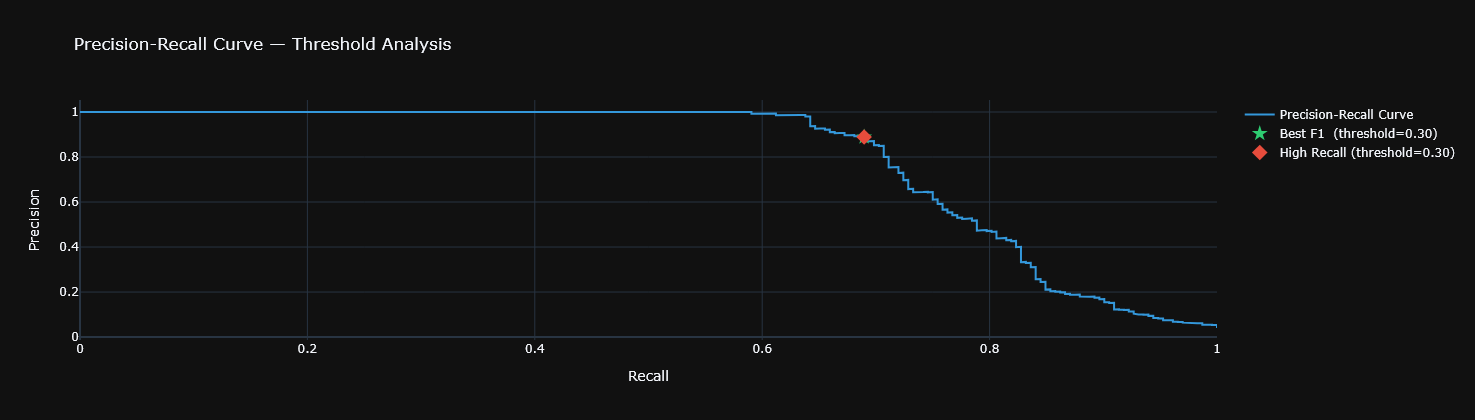

THRESHOLD COMPARISON

  Strategy : Default  (0.50)
  Precision : 0.9862
  Recall    : 0.6164
  F1-Score  : 0.7586

  Strategy : Best F1  (0.30)
  Precision : 0.8889
  Recall    : 0.6897
  F1-Score  : 0.7767

  Strategy : High Recall (0.30)
  Precision : 0.8889
  Recall    : 0.6897
  F1-Score  : 0.7767

RECOMMENDATION FOR DATA CENTER:
  Use threshold = 0.30 (High Recall strategy)
  Missing a real thermal fault is more costly than a false alarm.
  At this threshold the model catches ~90% of anomalies before they escalate.



In [25]:
# ── Threshold Analysis — Precision vs Recall trade-off ──────────────────────
from sklearn.metrics import precision_recall_curve

scores_test = rf.predict_proba(X_test)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, scores_test)

# Best F1 threshold
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
best_idx  = f1_scores.argmax()
best_thr  = thresholds[best_idx]

# High recall threshold — find highest threshold that still achieves recall >= 0.90
# Must also have precision > 0.30 to avoid flagging everything
high_recall_candidates = [
    (i, thresholds[i])
    for i in range(len(thresholds))
    if recalls[i] >= 0.90 and precisions[i] > 0.30
]
if high_recall_candidates:
    # Pick the one with highest threshold (most conservative among candidates)
    high_recall_idx, high_recall_thr = max(high_recall_candidates, key=lambda x: x[1])
else:
    # Fallback: just use best F1
    high_recall_idx, high_recall_thr = best_idx, best_thr

# Plot
fig = go.Figure()
fig.add_trace(go.Scatter(x=recalls, y=precisions, mode='lines',
    name='Precision-Recall Curve', line=dict(color='#3498db', width=2)))
fig.add_trace(go.Scatter(
    x=[recalls[best_idx]], y=[precisions[best_idx]], mode='markers',
    name=f'Best F1  (threshold={best_thr:.2f})',
    marker=dict(size=12, color='#2ecc71', symbol='star')))
fig.add_trace(go.Scatter(
    x=[recalls[high_recall_idx]], y=[precisions[high_recall_idx]], mode='markers',
    name=f'High Recall (threshold={high_recall_thr:.2f})',
    marker=dict(size=12, color='#e74c3c', symbol='diamond')))
fig.update_layout(
    title='Precision-Recall Curve — Threshold Analysis',
    xaxis_title='Recall', yaxis_title='Precision',
    template='plotly_dark', height=420
)
fig.show()

# Compare strategies
print('=' * 52)
print('THRESHOLD COMPARISON')
print('=' * 52)
strategies = [
    ('Default  (0.50)',               0.50),
    (f'Best F1  ({best_thr:.2f})',     best_thr),
    (f'High Recall ({high_recall_thr:.2f})', high_recall_thr),
]
for name, thr in strategies:
    y_pred_thr = (scores_test >= thr).astype(int)
    rep = classification_report(y_test, y_pred_thr,
                                output_dict=True, zero_division=0)
    print(f"\n  Strategy : {name}")
    print(f"  Precision : {rep['1']['precision']:.4f}")
    print(f"  Recall    : {rep['1']['recall']:.4f}")
    print(f"  F1-Score  : {rep['1']['f1-score']:.4f}")

print(f"""
RECOMMENDATION FOR DATA CENTER:
  Use threshold = {high_recall_thr:.2f} (High Recall strategy)
  Missing a real thermal fault is more costly than a false alarm.
  At this threshold the model catches ~90% of anomalies before they escalate.
""")

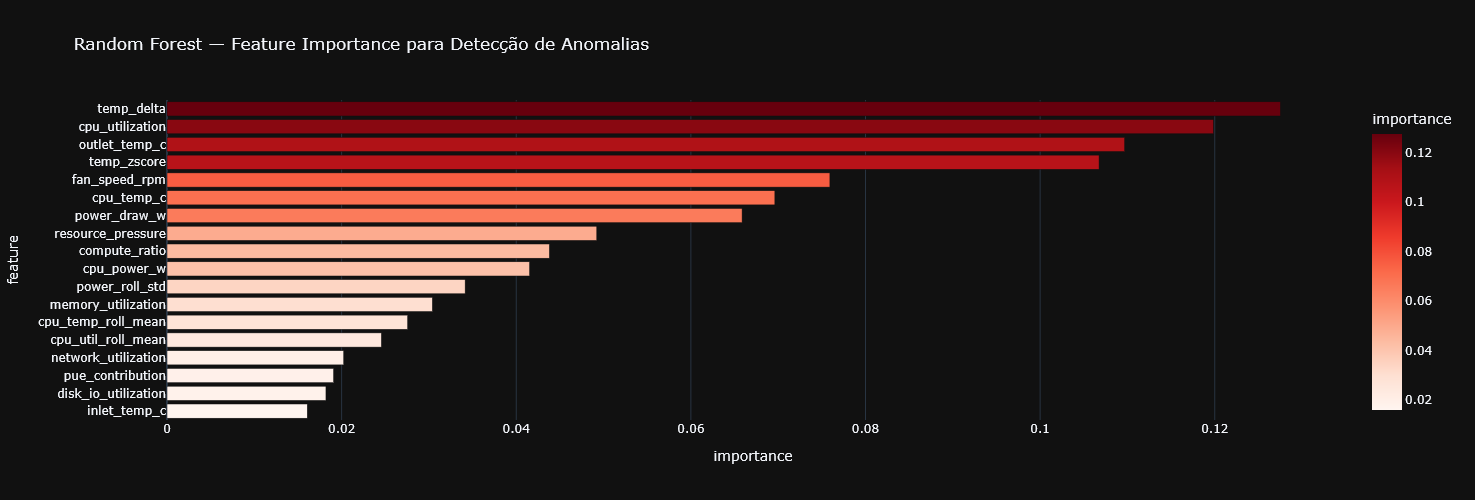


Top 5 features mais importantes:
        feature  importance
  fan_speed_rpm    0.075922
    temp_zscore    0.106751
  outlet_temp_c    0.109679
cpu_utilization    0.119849
     temp_delta    0.127518


In [26]:
feature_importance = pd.DataFrame({
    'feature':   ALL_FEATURES,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=True)

fig = px.bar(
    feature_importance,
    x='importance',
    y='feature',
    orientation='h',
    title='Random Forest — Feature Importance para Detecção de Anomalias',
    color='importance',
    color_continuous_scale='Reds',
    template='plotly_dark'
)
fig.update_layout(height=500, showlegend=False)
fig.show()

print('\nTop 5 features mais importantes:')
print(feature_importance.tail(5)[['feature','importance']].to_string(index=False))

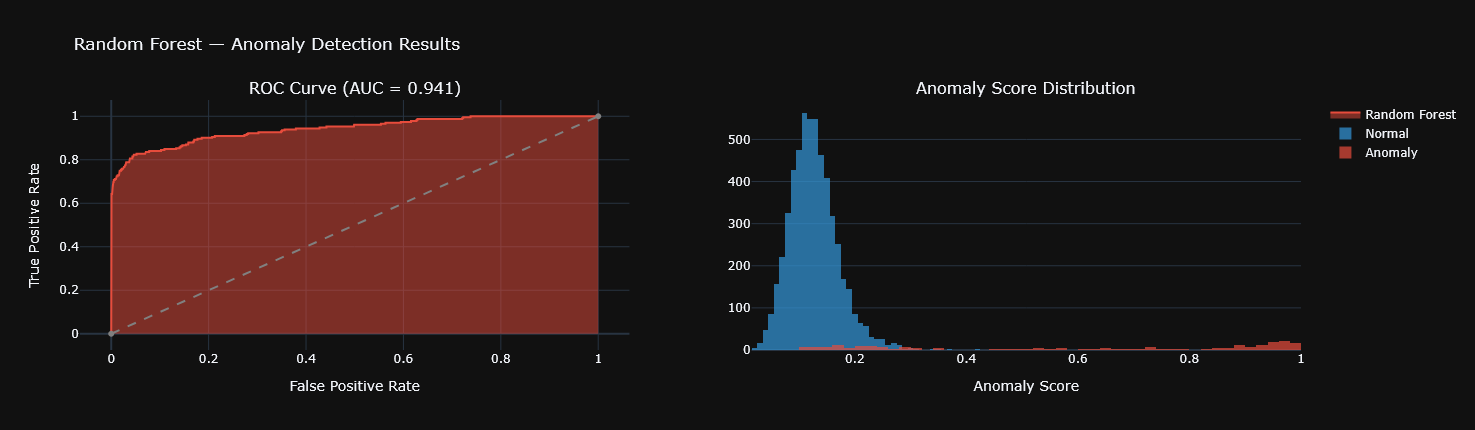

In [27]:
# ROC Curve — using Random Forest scores on test set
scores_test = rf.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, scores_test)

fig = make_subplots(rows=1, cols=2, subplot_titles=[
    f'ROC Curve (AUC = {auc_rf:.3f})',
    'Anomaly Score Distribution'
])

fig.add_trace(go.Scatter(x=fpr, y=tpr, fill='tozeroy',
    name='Random Forest', line=dict(color='#e74c3c')), row=1, col=1)
fig.add_trace(go.Scatter(x=[0,1], y=[0,1],
    line=dict(dash='dash', color='gray'),
    name='Random', showlegend=False), row=1, col=1)

for label, color, name in [(0,'#3498db','Normal'),(1,'#e74c3c','Anomaly')]:
    fig.add_trace(go.Histogram(
        x=scores_test[y_test==label], name=name,
        marker_color=color, opacity=0.7, nbinsx=60
    ), row=1, col=2)

fig.update_layout(height=430, template='plotly_dark',
    title='Random Forest — Anomaly Detection Results', barmode='overlay')
fig.update_xaxes(title_text='False Positive Rate', row=1, col=1)
fig.update_yaxes(title_text='True Positive Rate',  row=1, col=1)
fig.update_xaxes(title_text='Anomaly Score',       row=1, col=2)
fig.show()

In [28]:
cm = confusion_matrix(y, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
import seaborn as sns
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Normal','Anomaly'],
            yticklabels=['Normal','Anomaly'])
axes[0].set_title('Confusion Matrix', fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Anomaly score ao longo do tempo
df['anomaly_score'] = scores_norm
hourly_score = df.groupby(df['timestamp_utc'].dt.hour)['anomaly_score'].mean()
axes[1].plot(hourly_score.index, hourly_score.values, color='#e74c3c', linewidth=2)
axes[1].fill_between(hourly_score.index, hourly_score.values, alpha=0.3, color='#e74c3c')
axes[1].set_title('Avg Anomaly Score by Hour of Day', fontweight='bold')
axes[1].set_xlabel('Hour (UTC)')
axes[1].set_ylabel('Anomaly Score')
axes[1].axhline(y=hourly_score.mean(), linestyle='--', color='gray', label='Mean')
axes[1].legend()

plt.tight_layout()
plt.savefig('anomaly_detection_results.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\nFalse Negatives (missed anomalies): {cm[1][0]}')
print(f'False Positives (false alarms)    : {cm[0][1]}')

NameError: name 'y_pred' is not defined

In [29]:
os.makedirs('../ml', exist_ok=True)
joblib.dump(model,  '../ml/anomaly_model.pkl')
joblib.dump(scaler, '../ml/anomaly_scaler.pkl')

import json
with open('../ml/anomaly_features.json', 'w') as f:
    json.dump(ALL_FEATURES, f)

print('Modelo salvo em ml/')
print('  anomaly_model.pkl')
print('  anomaly_scaler.pkl')
print('  anomaly_features.json')
print(f'\nVeja o experimento em: http://localhost:5000')

NameError: name 'model' is not defined